In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = ""

# Load the latest version
path = kagglehub.dataset_download(
  "ruchi798/data-science-job-salaries",
)

print("Path to dataset files:", path)

link = "https://www.kaggle.com/datasets/ruchi798/data-science-job-salaries"

c:\Nyeh\Code\Python\Machine_Learning\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\Administrator\.cache\kagglehub\datasets\ruchi798\data-science-job-salaries\versions\1


In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error as MSE, r2_score
from sklearn.linear_model import LinearRegression

In [3]:
data = pd.read_csv(os.path.join(path, os.listdir(path)[0]))
data = data.drop(columns=["Unnamed: 0", "salary_currency", "salary_in_usd"])
data.head()

,work_year,experience_level,employment_type,job_title,salary,employee_residence,remote_ratio,company_location,company_size
0,2020,MI,FT,Data Scientist,70000,DE,0,DE,L
1,2020,SE,FT,Machine Learning Scientist,260000,JP,0,JP,S
2,2020,SE,FT,Big Data Engineer,85000,GB,50,GB,M
3,2020,MI,FT,Product Data Analyst,20000,HN,0,HN,S
4,2020,SE,FT,Machine Learning Engineer,150000,US,50,US,L


In [4]:
def categorize_job(title):
    title = title.lower()
    if "data scientist" in title:
        return "Data Scientist"
    elif "data analyst" in title or "analytics" in title:
        return "Data Analyst"
    elif "data engineer" in title or "etl" in title or "architect" in title:
        return "Data Engineer"
    elif "machine learning" in title or "ml" in title or "ai" in title:
        return "AI/ML Engineer"
    elif "manager" in title or "head" in title or "director" in title or "lead" in title:
        return "Manager"
    else:
        return "Other"

In [5]:
data["job_category"] = data["job_title"].apply(categorize_job)
data_job_category = data.drop(columns=["job_title"])
# categorical_val = data.select_dtypes(include=["str"]).columns.tolist()
# print(categorical_val)
# data.info()
# data_job_category["salary"].describe()
job_salary_means = data_job_category.groupby("job_category")["salary"].mean()
job_salary_means_df=  job_salary_means.reset_index()
job_salary_means_df.sort_values(by="salary", ascending=False).head()

,job_category,salary
4,Manager,552609.214286
0,AI/ML Engineer,505828.440000
3,Data Scientist,493161.320755
1,Data Analyst,206606.614815
2,Data Engineer,188755.261628


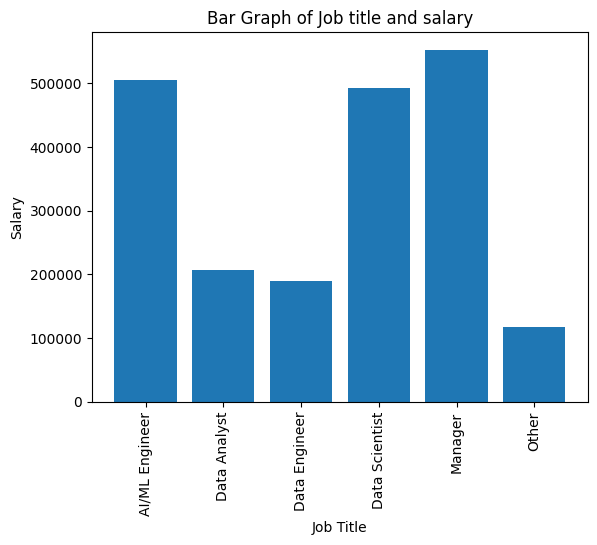

In [6]:
plt.bar(job_salary_means_df["job_category"], job_salary_means_df["salary"])
plt.title("Bar Graph of Job title and salary")
plt.xlabel("Job Title")
plt.xticks(rotation=90)
plt.ylabel("Salary")
plt.show()

In [7]:
def categorize_regions(country):
    europe = ['DE','GB','HU','FR','PL','PT','GR','NL','AT','ES','DK','RU','IT',
              'HR','BG','BE','UA','MT','RO','SI','RS','LU','JE','CZ','EE','IE','CH']
    
    asia = ['JP','IN','PK','CN','AE','SG','IQ','VN','IR','HK','TR','MY','PH']
    
    north_america = ['US','CA','MX','PR']
    
    south_america = ['BR','CL','CO','AR','BO']
    
    africa = ['NG','KE','DZ','TN']
    
    oceania = ['AU','NZ']
    
    if country in europe:
        return "Europe"
    elif country in asia:
        return "Asia"
    elif country in north_america:
        return "North America"
    elif country in south_america:
        return "South America"
    elif country in africa:
        return "Africa"
    elif country in oceania:
        return "Oceania"
    else:
        return "Other"

In [ ]:

# for i in data_job_category.select_dtypes(include=["str"]).columns:
#     print(i, " ", data_job_category[i].nunique())

data_job_category["employee_continent"] = data_job_category["employee_residence"].apply(categorize_regions)
data_job_category["company_continent"] = data_job_category["company_location"].apply(categorize_regions)
data_job_category.head()

data_categorised = data_job_category.copy()
data_categorised = data_categorised.drop(columns=["company_location", "employee_residence"])

# for i in data_categorised.select_dtypes(include=["str"]).columns:
    # print(i, " ", data_categorised[i].nunique())

data_categorised.head()

,work_year,experience_level,employment_type,salary,remote_ratio,company_size,job_category,employee_continent,company_continent
0,2020,MI,FT,70000,0,L,Data Scientist,Europe,Europe
1,2020,SE,FT,260000,0,S,AI/ML Engineer,Asia,Asia
2,2020,SE,FT,85000,50,M,Data Engineer,Europe,Europe
3,2020,MI,FT,20000,0,S,Data Analyst,Other,Other
4,2020,SE,FT,150000,50,L,AI/ML Engineer,North America,North America


In [ ]:
dummies = pd.get_dummies(data_categorised, drop_first=True)
dummies.head()

X = dummies.drop("salary", axis=1).values
y = dummies["salary"].values

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

linreg = LinearRegression()
linreg.fit(X_train, y_train)
y_pred = linreg.predict(X_test)

rsqr = linreg.score(X_test, y_test)
mean_squared_error = MSE(y_test, y_pred)
root_mean_squared_error = np.sqrt(mean_squared_error)

print(f"R-Square Score: {rsqr}")
print(f"MEAN SQUARED_ERROR: {mean_squared_error}")
print(f"ROOT MEAN SQUARED_ERROR: {root_mean_squared_error}")

R-Square Score: 0.007622789809064279
MEAN SQUARED_ERROR: 8021573758540.561
ROOT MEAN SQUARED_ERROR: 2832238.29480158
